In [122]:
import json
import pandas as pd
import glob
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import unicodedata
from underthesea import word_tokenize, sent_tokenize
import string
from nltk.util import ngrams
from collections import Counter
from wordcloud import WordCloud

In [2]:
files = glob.glob("../data/parsed/*.json")

prs = []
chs = []
sec = []
art = []
cla = []
pts = []

for f in files:
    with open(f, "r", encoding="utf-8") as file:
        data = json.load(file)
        nodes = data["nodes"]
        for pa in nodes["parts"]:
            prs.append(pa)
        for ch in nodes["chapters"]:
            chs.append(ch)
        for se in nodes["sections"]:
            sec.append(se)
        for ar in nodes["articles"]:
            art.append(ar)
        for cl in nodes["clauses"]:
            cla.append(cl)
        for pt in nodes["points"]:
            pts.append(pt)

parts = pd.DataFrame(prs)
chapters = pd.DataFrame(chs)
sections = pd.DataFrame(sec)
articles = pd.DataFrame(art)
clauses = pd.DataFrame(cla)
points = pd.DataFrame(pts)

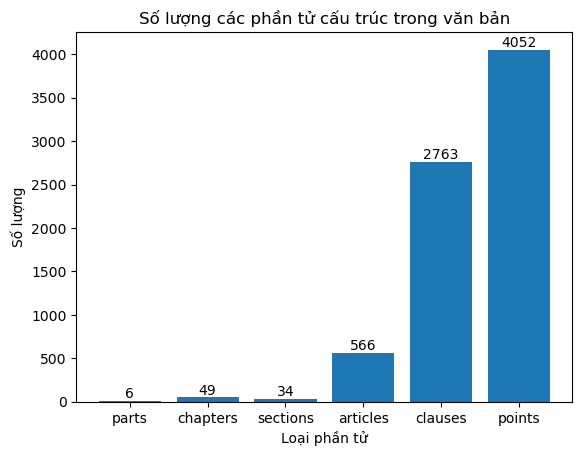

In [3]:
counts = {
    "parts": len(parts),
    "chapters": len(chapters),
    "sections": len(sections),
    "articles": len(articles),
    "clauses": len(clauses),
    "points": len(points)
}
labels = list(counts.keys())
values = list(counts.values())
bars = plt.bar(labels, values)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(int(height)),
             ha='center', va='bottom')
plt.title("Số lượng các phần tử cấu trúc trong văn bản")
plt.xlabel("Loại phần tử")
plt.ylabel("Số lượng")
plt.show()

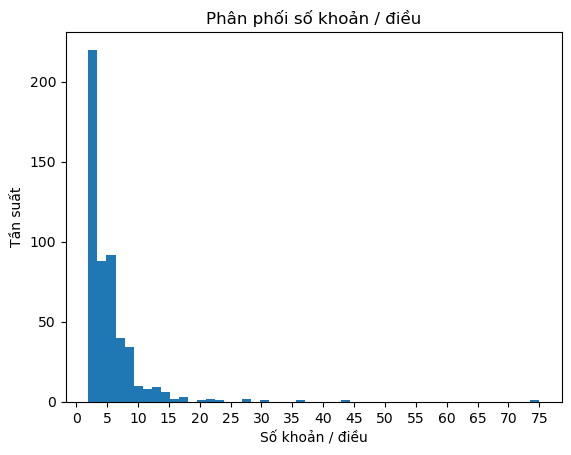

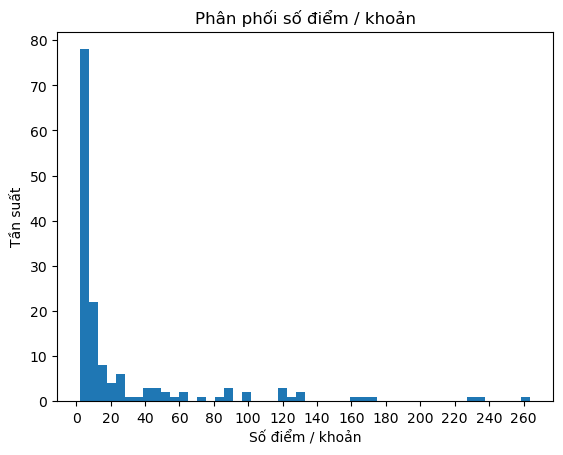

In [4]:
clause_count = clauses.groupby(["doc_identity", "parent_article"]).size()
plt.hist(clause_count, bins=50)
plt.gca().xaxis.set_major_locator(MultipleLocator(5))
plt.title("Phân phối số khoản / điều")
plt.xlabel("Số khoản / điều")
plt.ylabel("Tần suất")
plt.show()
point_count = points.groupby(["doc_identity", "parent_clause"]).size()
plt.hist(point_count, bins=50)
plt.gca().xaxis.set_major_locator(MultipleLocator(20))
plt.title("Phân phối số điểm / khoản")
plt.xlabel("Số điểm / khoản")
plt.ylabel("Tần suất")
plt.show()

In [78]:
text_cols = [
    "content",
    "title",
]
texts = []
for col in text_cols:
    for df in [parts, chapters, sections, articles, clauses, points]:
        if col in df:
            texts.extend(
                [x for x in df[col].dropna().astype(str) if x.strip() != ""]
            )
texts = [
    unicodedata.normalize("NFC", t).lower()
    for t in texts
]

In [79]:
with open("vietnamese-stopwords.txt", encoding="utf-8") as f:
    stopwords = set(f.read().splitlines())

In [80]:
# def has_punctuation(s):
#     return any(unicodedata.category(c).startswith("P") for c in s)
tokens = []
for text in texts:
    tk = word_tokenize(text)
    # tk = [t for t in tk if not has_punctuation(t)]
    tk = [t for t in tk if t not in stopwords]
    tokens.extend(tk)

In [81]:
tokens = [t for t in tokens if len(t) > 1]
len(tokens)

138434

In [82]:
len(set(tokens))

3344

In [83]:
len(set(tokens))/len(tokens)

0.02415591545429591

In [119]:
df_text = pd.DataFrame({
    "content": texts
})
df_text["tokens"] = df_text["content"].apply(lambda x: word_tokenize(x))
df_text["length"] = df_text["tokens"].apply(len)

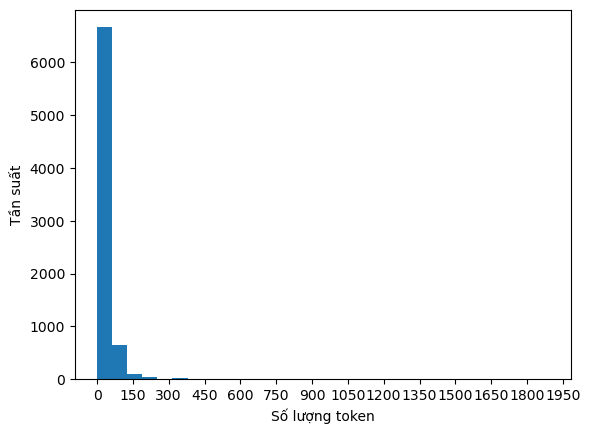

In [125]:
plt.hist(df_text["length"], bins=30)
plt.gca().xaxis.set_major_locator(MultipleLocator(150))
plt.xlabel("Số lượng token")
plt.ylabel("Tần suất")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_30316\222046944.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([article_wc, clause_wc, point_wc], labels=["Article","Clause","Point"])


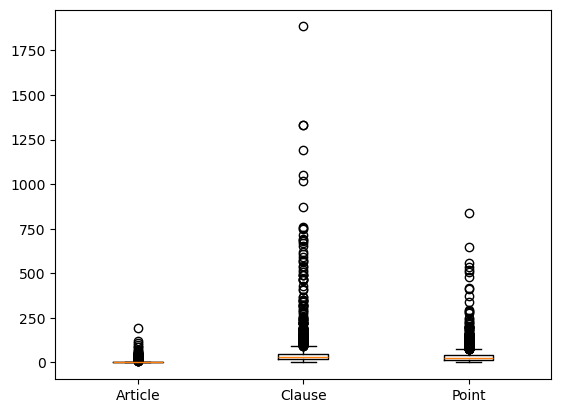

In [121]:
def word_count(text):
    tokens = word_tokenize(text)
    return len(tokens)
article_texts = articles["content"].dropna().tolist()
clause_texts = clauses["content"].dropna().tolist()
point_texts = points["content"].dropna().tolist()
article_wc = [word_count(t) for t in article_texts]
clause_wc = [word_count(t) for t in clause_texts]
point_wc = [word_count(t) for t in point_texts]
plt.boxplot([article_wc, clause_wc, point_wc], labels=["Article","Clause","Point"])
plt.show()

In [126]:
def count_sentences(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0
    sentences = sent_tokenize(text)
    return len(sentences)

In [127]:
full_text = " ".join(texts)  # texts là list bạn đã extract
full_sent_count = count_sentences(full_text)
print("Full text sentence count:", full_sent_count)

Full text sentence count: 8240


In [ ]:
# not done
article_texts = [
    a["content"] for a in articles
    if isinstance(a, dict) and "content" in a
]
clause_texts = [
    c["content"] for c in clauses
    if isinstance(c, dict) and "content" in c
]
point_texts = [
    p["content"] for p in points
    if isinstance(p, dict) and "content" in p
]
article_sent = [count_sentences(t) for t in article_texts]
clause_sent = [count_sentences(t) for t in clause_texts]
point_sent = [count_sentences(t) for t in point_texts]

[]


C:\Users\DELL\AppData\Local\Temp\ipykernel_30316\1294523762.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Article", "Clause", "Point"])


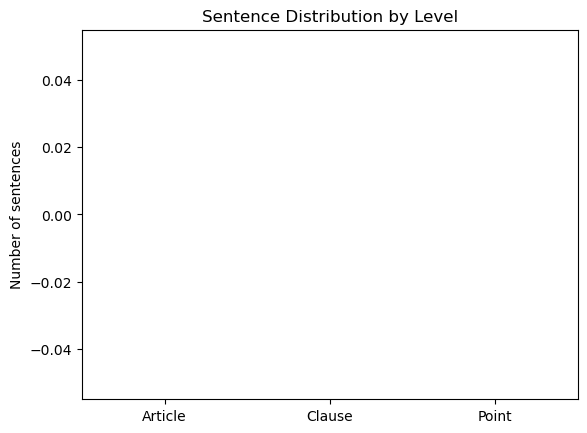

In [ ]:
# not done
data = [article_sent, clause_sent, point_sent]

plt.boxplot(data, labels=["Article", "Clause", "Point"])

plt.ylabel("Number of sentences")
plt.title("Sentence Distribution by Level")

plt.show()

In [102]:
word_freq = Counter(tokens)

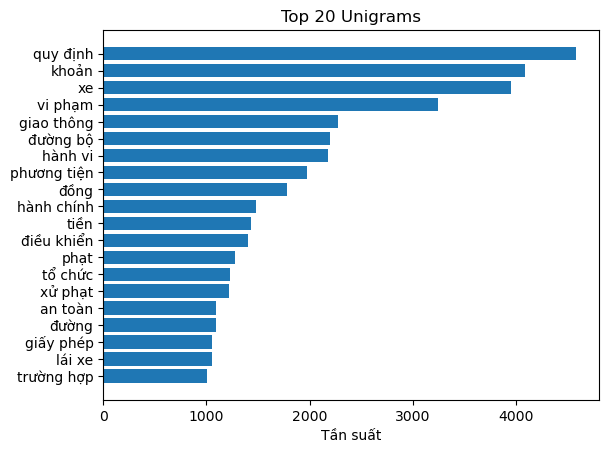

In [103]:
top_words = word_freq.most_common(20)
words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]
plt.barh(words, counts)
plt.xlabel("Tần suất")
plt.title("Top 20 Unigrams")
plt.gca().invert_yaxis()
plt.show()

In [87]:
redundant = ["điều", "khoản", "điểm", "đồng"]

In [110]:
bigrams = list(ngrams(tokens, 2))
bigrams = [bg for bg in bigrams if bg[0] != bg[1]]
# bigrams = [
#     (w1, w2)
#     for w1, w2 in bigrams
#     if w1 not in redundant and w2 not in redundant
# ]

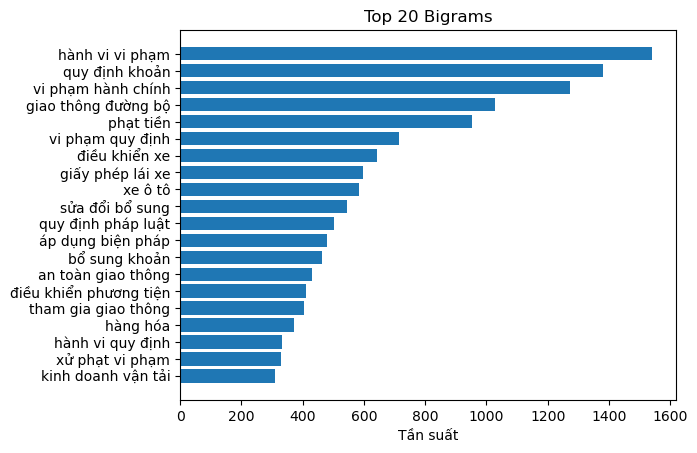

In [111]:
bi = Counter(bigrams).most_common(20)
words = [" ".join(x[0]) for x in bi]
counts = [x[1] for x in bi]
plt.barh(words, counts)
plt.xlabel("Tần suất")
plt.title("Top 20 Bigrams")
plt.gca().invert_yaxis()
plt.show()

In [116]:
word_freqs = {" ".join(k): v for k, v in Counter(bigrams).items()}

In [107]:
trigrams = list(ngrams(tokens, 3))
trigrams = [tg for tg in trigrams if tg[0] != tg[1] and tg[0] != tg[2] and tg[1] != tg[2]]
# trigrams = [
#     (w1, w2, w3)
#     for w1, w2, w3 in trigrams
#     if w1 not in redundant and w2 not in redundant and w3 not in redundant
# ]

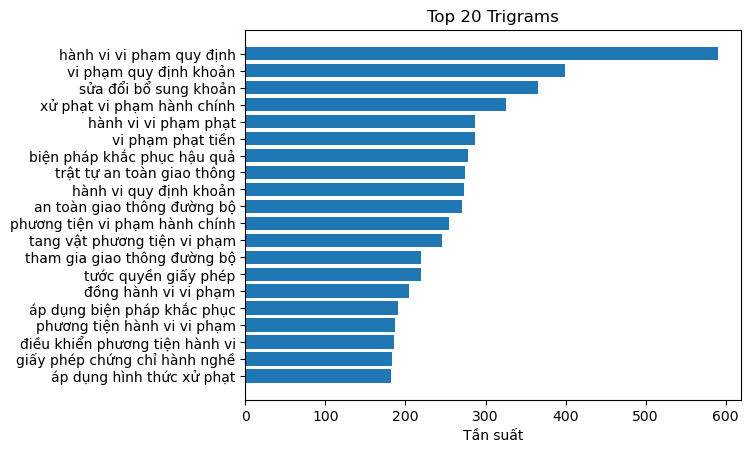

In [108]:
tri = Counter(trigrams).most_common(20)
words = [" ".join(x[0]) for x in tri]
counts = [x[1] for x in tri]
plt.barh(words, counts)
plt.xlabel("Tần suất")
plt.title("Top 20 Trigrams")
plt.gca().invert_yaxis()
plt.show()

In [112]:
quadgrams = list(ngrams(tokens, 4))
quadgrams = [qg for qg in quadgrams if qg[0] != qg[1] and qg[0] != qg[2] and qg[0] != qg[3] and qg[1] != qg[2] and qg[1] != qg[3] and qg[2] != qg[3]]
# quadgrams = [
#     (w1, w2, w3, w4)
#     for w1, w2, w3, w4 in trigrams
#     if w1 not in redundant and w2 not in redundant and w3 not in redundant and w4 not in redundant
# ]

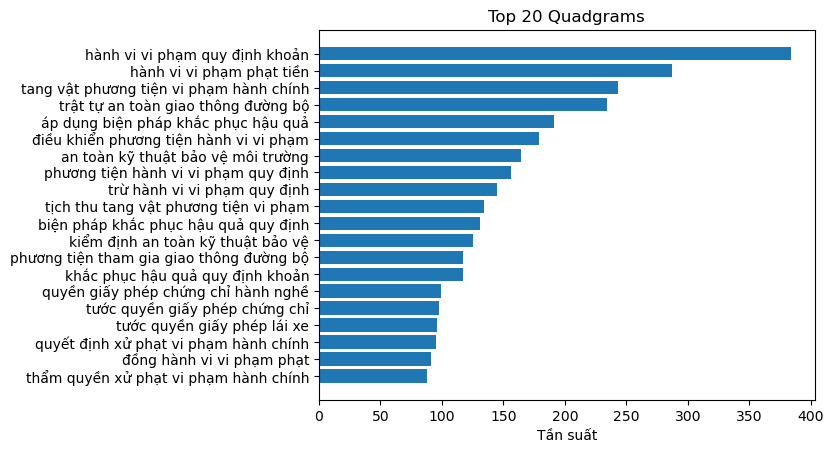

In [114]:
quad = Counter(quadgrams).most_common(20)
words = [" ".join(x[0]) for x in quad]
counts = [x[1] for x in quad]
plt.barh(words, counts)
plt.xlabel("Tần suất")
plt.title("Top 20 Quadgrams")
plt.gca().invert_yaxis()
plt.show()

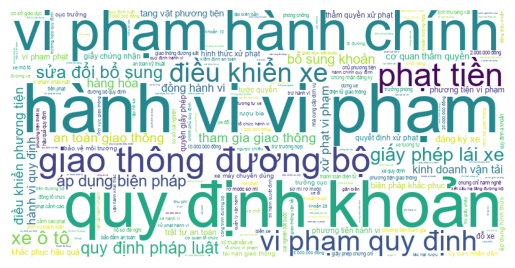

In [117]:
wordcloud = WordCloud(
    font_path="arial.ttf",
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(word_freqs)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()